# BQ2 — รูปแบบการถือครองให้ผลต่างกันอย่างไร

**คำถาม:** รูปแบบการถือครองแบบใดให้ผลต่างกันอย่างไร ทั้งด้าน**คุณภาพ**, **ชั่วโมงพยาบาล**
และ**ค่าปรับต่อเตียง** — ผู้ใช้คือ CEO และ CFO

ข้อนี้ต้องใช้ **ทั้งสองตาราง Fact** ซึ่งเป็นครั้งแรกในโครงงานนี้:
`Fact_Facility_Monthly` (คุณภาพ ชั่วโมงพยาบาล) และ `Fact_Penalty_Event` (ค่าปรับ)

**กับดักที่ต้องระวังก่อนอย่างอื่น:** สอง Fact นี้มี Grain ต่างกัน
— Fact 1 มีหนึ่งแถวต่อสถานพยาบาลต่องวด แต่ Fact 2 มีหนึ่งแถวต่อค่าปรับหนึ่งใบ
ถ้า `JOIN` ตรง ๆ เตียงของสถานพยาบาลจะถูกนับซ้ำหนึ่งครั้งต่อค่าปรับหนึ่งใบ
ตัวหารทุกตัวจะพองขึ้นทันที

`queries.segment_compare()` จึง **รวมค่าแต่ละ Fact แยกกันให้เหลือระดับกลุ่มก่อน
แล้วค่อยเชื่อมกันที่ระดับกลุ่ม** ไม่เชื่อกันแบบแถวต่อแถว

## 1. ต่อฐานข้อมูล

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import charts
import queries as q

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

con = q.connect()
print(q.available_periods(con).to_string(index=False))

 period_key     period  year  facilities
   20190101 2019-01-01  2019       15578
   20260401 2026-04-01  2026       14699
   20260601 2026-06-01  2026       14695
   20260701 2026-07-01  2026       14693


## 2. ทำไมต้องตอบที่ระดับ 3 กลุ่ม ไม่ใช่ 13 ประเภท

ก่อนจะเปรียบเทียบ ต้องรู้ก่อนว่าหน่วยที่ใช้เปรียบเทียบมีเสถียรภาพพอไหม
เซลล์นี้นับว่าสถานพยาบาลเปลี่ยนประเภทการถือครองบ่อยแค่ไหน — ถ้าเปลี่ยนบ่อย
การเปรียบเทียบ "ประเภท" จะวัดการเปลี่ยนกระดาษ ไม่ใช่การเปลี่ยนผู้บริหาร

In [2]:
churn = con.execute("""
    WITH a AS (SELECT f.ccn, o.ownership_type AS t2019, o.ownership_group AS g2019
               FROM Fact_Facility_Monthly f JOIN Dim_Ownership o USING(ownership_key)
               WHERE f.snapshot_date_key = 20190101),
         b AS (SELECT f.ccn, o.ownership_type AS t2026, o.ownership_group AS g2026
               FROM Fact_Facility_Monthly f JOIN Dim_Ownership o USING(ownership_key)
               WHERE f.snapshot_date_key = 20260701)
    SELECT COUNT(*)                                          AS facilities_in_both,
           SUM(CASE WHEN t2019 <> t2026 THEN 1 ELSE 0 END)    AS type_changed,
           SUM(CASE WHEN g2019 <> g2026 THEN 1 ELSE 0 END)    AS group_changed
    FROM a JOIN b USING(ccn)
""").df()
print(churn.to_string(index=False))

print("\nการเปลี่ยนประเภทที่พบบ่อยที่สุด:")
print(con.execute("""
    WITH a AS (SELECT f.ccn, o.ownership_type AS t2019 FROM Fact_Facility_Monthly f
               JOIN Dim_Ownership o USING(ownership_key) WHERE f.snapshot_date_key = 20190101),
         b AS (SELECT f.ccn, o.ownership_type AS t2026 FROM Fact_Facility_Monthly f
               JOIN Dim_Ownership o USING(ownership_key) WHERE f.snapshot_date_key = 20260701)
    SELECT t2019, t2026, COUNT(*) n FROM a JOIN b USING(ccn)
    WHERE t2019 <> t2026 GROUP BY 1,2 ORDER BY n DESC LIMIT 4
""").df().to_string(index=False))

 facilities_in_both  type_changed  group_changed
              14292        7859.0         1509.0

การเปลี่ยนประเภทที่พบบ่อยที่สุด:
                   t2019                                  t2026    n
For profit - Corporation For profit - Limited Liability company 3777
For profit - Partnership For profit - Limited Liability company  487
For profit - Corporation                For profit - Individual  396
 For profit - Individual For profit - Limited Liability company  306


**ข้อสรุป:** ประเภทเปลี่ยนราวครึ่งหนึ่ง แต่**กลุ่ม**เปลี่ยนราว 10% เท่านั้น
และการเปลี่ยนที่พบบ่อยสุดคือ `For profit - Corporation` → `For profit - Limited Liability company`
ซึ่งเป็นการเปลี่ยน**รูปแบบนิติบุคคล** ไม่ใช่เปลี่ยนว่าใครบริหาร

→ ตอบ BQ2 ที่ระดับ **3 กลุ่ม** กฎ Q5 ในเอกสารออกแบบที่ยุบ 13 ประเภทเหลือ 3 กลุ่ม
จึงมีเหตุผลเชิงประจักษ์รองรับ ไม่ใช่แค่ความเป็นระเบียบ

## 3. ดึงข้อมูลเปรียบเทียบ

In [3]:
frame, context = q.segment_compare(con, "ownership_group")
for key, value in context.items():
    print(f"  {key:<22} {value}")

  segment                ownership_group
  segment_label          ownership group
  period_key             20260701
  period                 2026-07-01
  fines_window           2023-07-01 to 2026-07-01
  fines_window_years     3
  exclude_suspect        True
  facilities             14667
  beds                   1566875


In [4]:
frame[["segment", "facilities", "beds", "occupancy", "avg_rating",
       "nurse_hprd", "rn_hprd", "rn_share", "turnover_pct",
       "fines_per_bed", "share_fined"]].round(4)

,segment,facilities,beds,occupancy,avg_rating,nurse_hprd,rn_hprd,rn_share,turnover_pct,fines_per_bed,share_fined
0,For profit,10845,1203047.0,0.8080,2.8042,3.6197,0.5734,0.1584,45.7902,351.2731,0.4869
1,Non profit,2875,258261.0,0.8029,3.5728,4.2064,0.8153,0.1938,40.3778,224.0573,0.3711
2,Government,947,105567.0,0.7281,3.2762,4.1666,0.7615,0.1828,42.4493,250.3615,0.4372


## 4. ตรวจว่าการถ่วงน้ำหนักสำคัญจริงไหม

`nurse_hprd` เป็น *ชั่วโมงต่อผู้พักอาศัยต่อวัน* คือเป็นอัตราต่อหัวอยู่แล้ว
การเฉลี่ยแบบไม่ถ่วงน้ำหนักจึงให้บ้าน 20 เตียงมีน้ำหนักเท่าบ้าน 300 เตียง
เซลล์นี้แสดงทั้งสองแบบเทียบกัน

In [5]:
compare = frame[["segment", "nurse_hprd", "nurse_hprd_unweighted",
                 "turnover_pct", "turnover_pct_unweighted"]].copy()
compare["hprd_gap"] = compare["nurse_hprd_unweighted"] - compare["nurse_hprd"]
compare.round(3)

,segment,nurse_hprd,nurse_hprd_unweighted,turnover_pct,turnover_pct_unweighted,hprd_gap
0,For profit,3.620,3.687,45.790,47.156,0.067
1,Non profit,4.206,4.398,40.378,41.221,0.191
2,Government,4.167,4.267,42.449,44.263,0.101


ค่าที่ไม่ถ่วงน้ำหนัก**สูงกว่าทุกกลุ่ม** เพราะบ้านเล็กมีชั่วโมงต่อหัวสูงกว่า
ถ้ารายงานตัวเลขไม่ถ่วงน้ำหนัก จะเป็นการอ้างว่าอุตสาหกรรมจัดพยาบาลมากกว่าความจริง

## 5. ตรวจว่าค่าปรับไม่ถูกนับซ้ำจากการเชื่อมสอง Fact

เซลล์นี้คำนวณค่าปรับของกลุ่ม for-profit ขึ้นมาใหม่แบบตรง ๆ แล้วเทียบกับที่ฟังก์ชันให้
ถ้าการเชื่อมสอง Fact ผิด ตัวเลขจะไม่ตรง

In [6]:
period_key, window = context["period_key"], context["fines_window"].split(" to ")

by_hand = con.execute("""
    WITH roster AS (
        SELECT f.ccn, f.certified_beds
        FROM Fact_Facility_Monthly f
        JOIN Dim_Ownership o USING(ownership_key)
        WHERE f.snapshot_date_key = ? AND o.ownership_group = 'For profit'
          AND NOT f.is_suspect
    )
    SELECT (SELECT SUM(certified_beds) FROM roster)                AS beds,
           SUM(p.fine_amount_usd)                                  AS fine_total,
           COUNT(DISTINCT p.ccn)                                   AS fined_facilities
    FROM Fact_Penalty_Event p
    JOIN Dim_Date d ON p.penalty_date_key = d.date_key
    JOIN roster r ON r.ccn = p.ccn
    WHERE d.full_date BETWEEN ? AND ?
""", [period_key, window[0], window[1]]).df().iloc[0]

row = frame.loc[frame["segment"] == "For profit"].iloc[0]
print(f"{'measure':<20}{'by hand':>16}{'from queries.py':>18}   match")
for key in ["beds", "fine_total", "fined_facilities"]:
    a, b = float(by_hand[key]), float(row[key])
    print(f"{key:<20}{a:>16,.0f}{b:>18,.0f}   {'OK' if abs(a-b) < 1 else 'MISMATCH'}")

fpb = float(by_hand["fine_total"]) / float(by_hand["beds"])
print(f"\nfines per bed by hand {fpb:,.2f}  vs  {row['fines_per_bed']:,.2f}")

wrong = con.execute("""
    SELECT SUM(f.certified_beds) FROM Fact_Facility_Monthly f
    JOIN Dim_Ownership o USING(ownership_key)
    JOIN Fact_Penalty_Event p ON p.ccn = f.ccn
    WHERE f.snapshot_date_key = ? AND o.ownership_group = 'For profit' AND NOT f.is_suspect
""", [period_key]).fetchone()[0]
print(f"\nถ้า JOIN สอง Fact ตรง ๆ เตียงจะกลายเป็น {wrong:,.0f}")
print(f"แทนที่จะเป็น {float(by_hand['beds']):,.0f} — พองขึ้น {wrong/float(by_hand['beds']):.1f} เท่า")

measure                      by hand   from queries.py   match
beds                       1,203,047         1,203,047   OK
fine_total               422,598,049       422,598,049   OK
fined_facilities               5,280             5,280   OK

fines per bed by hand 351.27  vs  351.27

ถ้า JOIN สอง Fact ตรง ๆ เตียงจะกลายเป็น 2,586,212
แทนที่จะเป็น 1,203,047 — พองขึ้น 2.1 เท่า


บรรทัดสุดท้ายคือเหตุผลที่ฟังก์ชันนี้รวมค่าแต่ละ Fact แยกกันก่อนแล้วจึงเชื่อมที่ระดับกลุ่ม

## 6. กราฟ C3 — เปรียบเทียบหกตัวชี้วัด

โจทย์วางไว้เป็น "แท่งกลุ่ม" แต่คะแนนดาวอยู่ช่วง 0–5 อัตราลาออก 0–100
และค่าปรับต่อเตียงเป็นหลักร้อยดอลลาร์ — วางบนแกนเดียวกันต้องใช้สองสเกล
ซึ่งจะสร้างความสัมพันธ์ปลอมขึ้นมา จึงแยกเป็นหนึ่งแผงต่อหนึ่งตัวชี้วัด
ทุกการเปรียบเทียบอยู่บนแกนเดียวที่ซื่อสัตย์

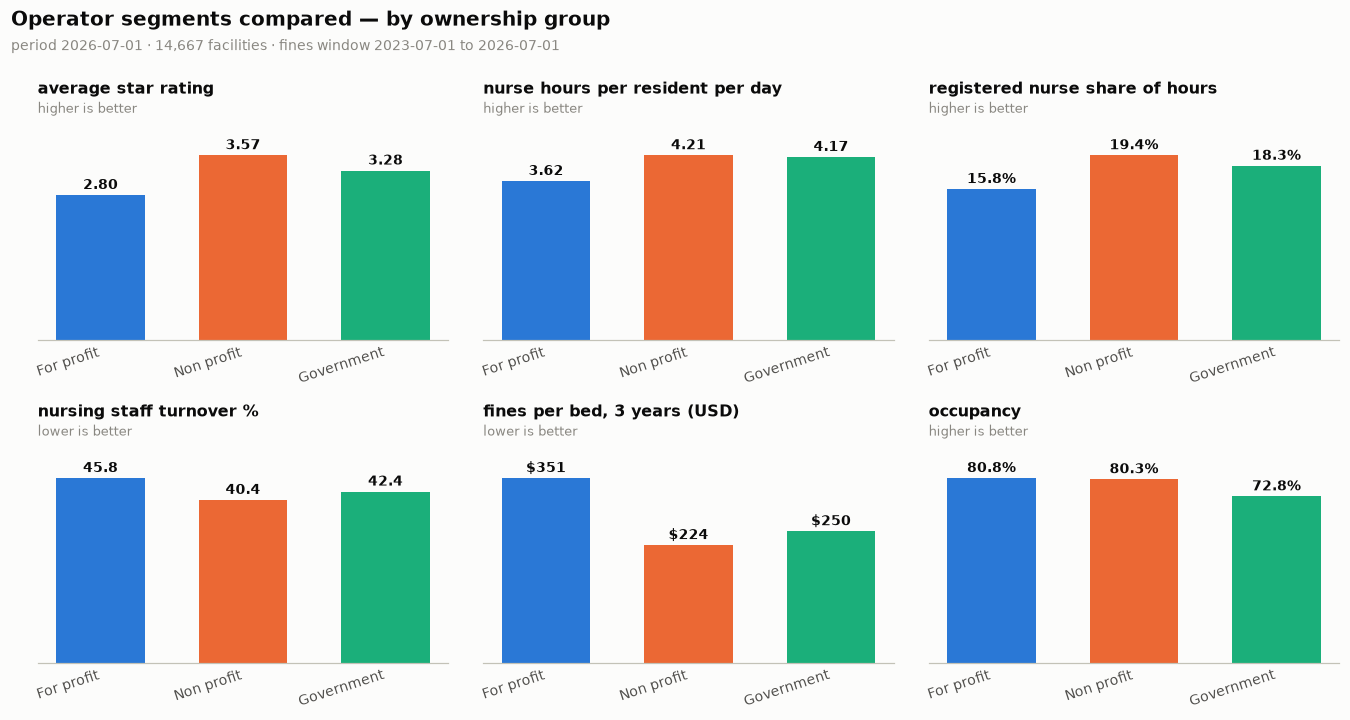

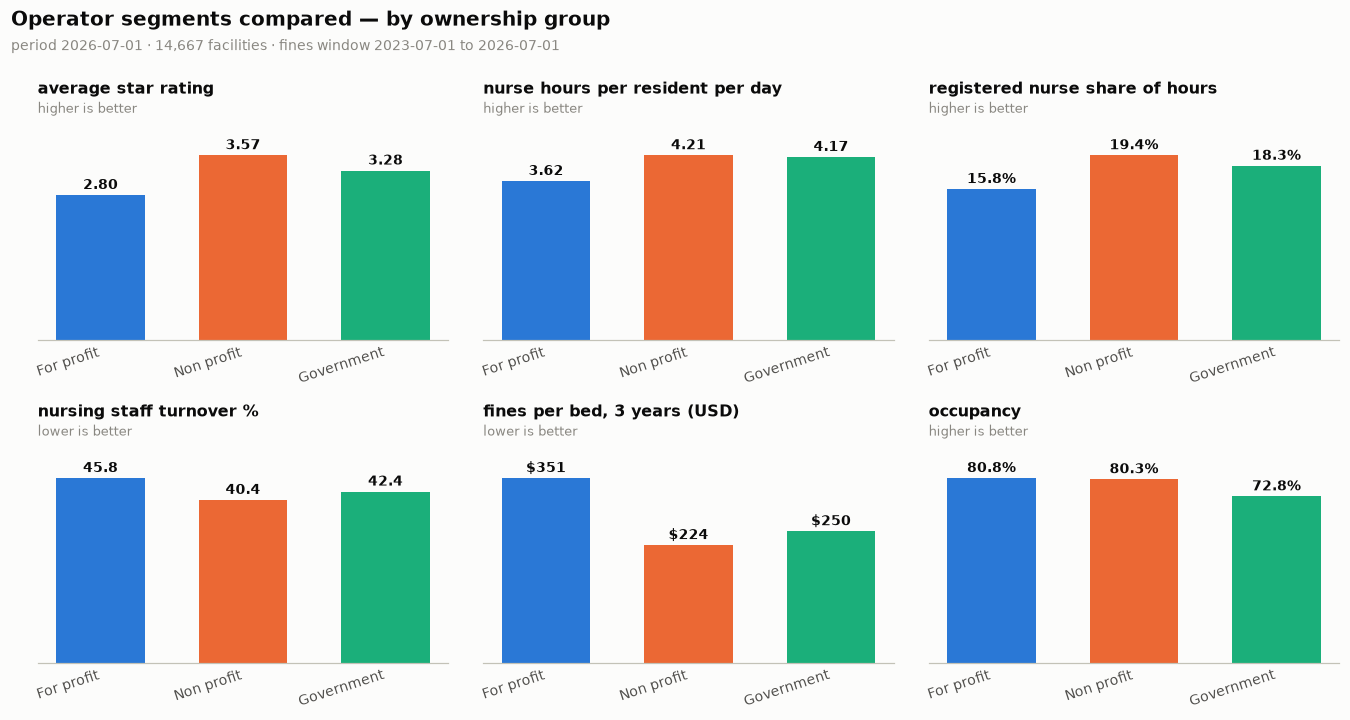

In [7]:
fig = charts.segment_small_multiples(frame, context)
fig.savefig("bq2_segments.png", dpi=150, bbox_inches="tight")
fig

## 7. ค่าเฉลี่ยซ่อนอะไรไว้

ค่าเฉลี่ยต่างกัน 0.77 ดาวฟังดูมาก แต่ไม่ได้บอกว่าแยกแยะบ้านแต่ละหลังได้หรือไม่
กราฟนี้แสดง**สัดส่วนของแต่ละระดับดาว** ซึ่งเป็นรูปแบบที่ถูกสำหรับคะแนนที่เป็นจำนวนเต็ม 1–5

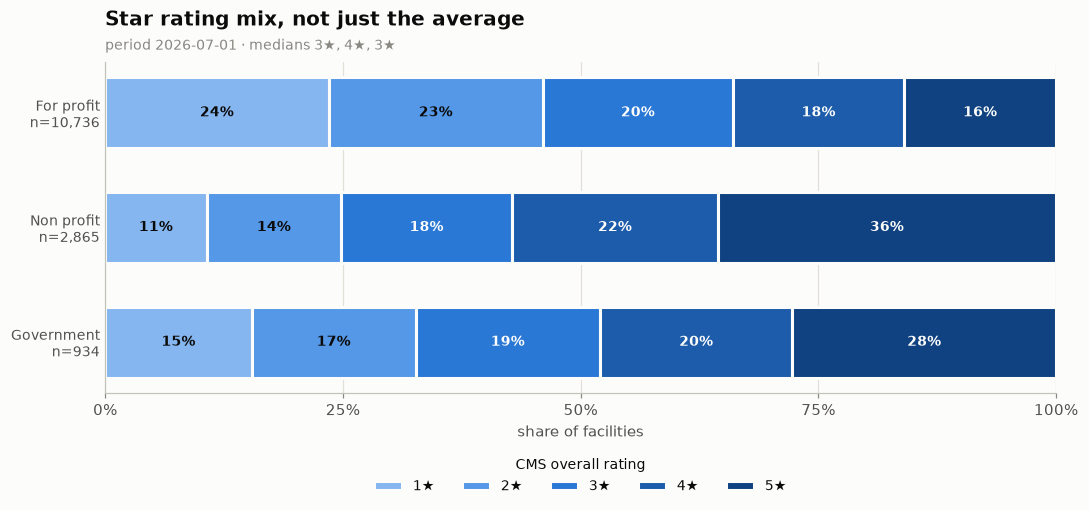

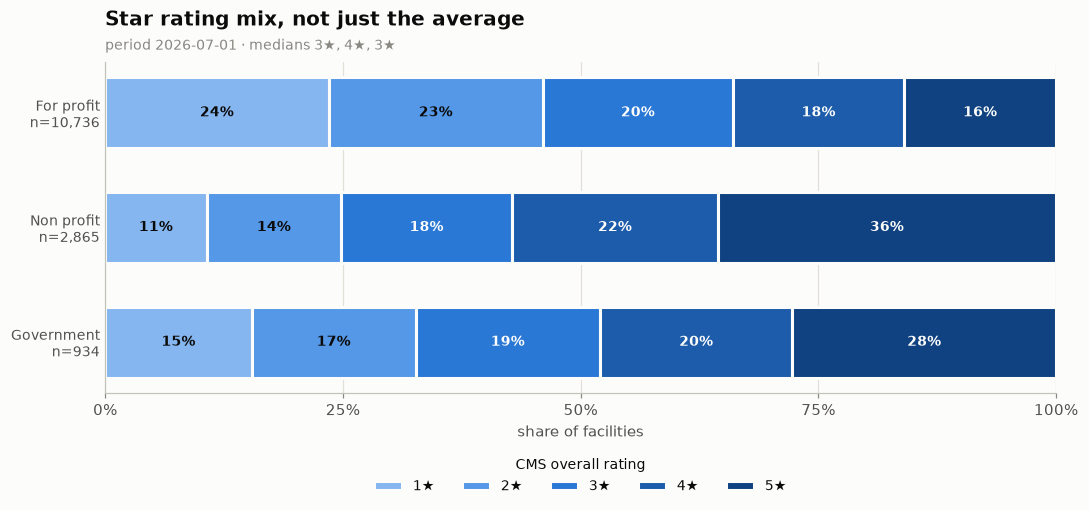

In [8]:
facilities = q.segment_facilities(con, "ownership_group")
fig = charts.rating_mix_by_segment(
    facilities, context, order=q.SEGMENTS["ownership_group"]["order"]
)
fig.savefig("bq2_rating_mix.png", dpi=150, bbox_inches="tight")
fig

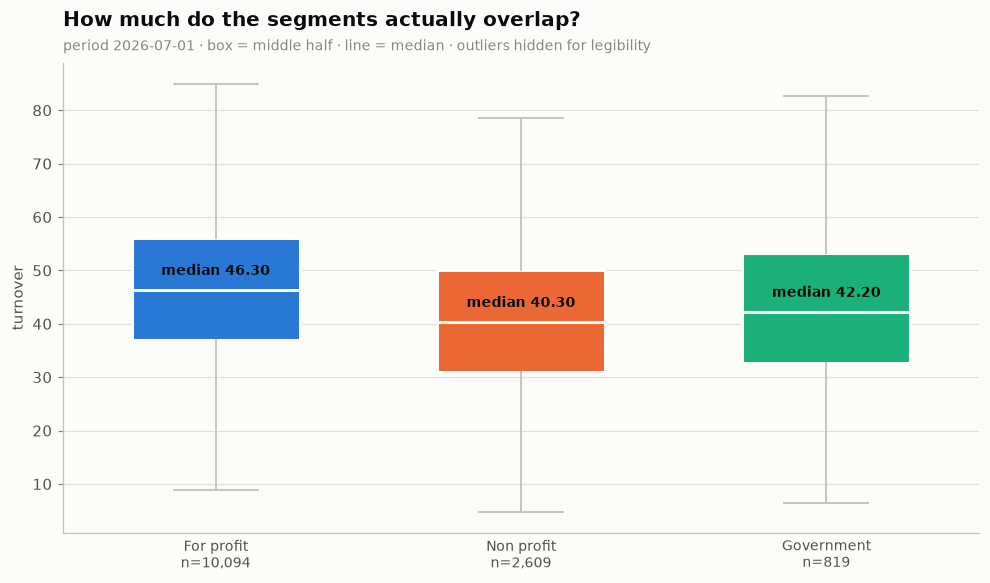

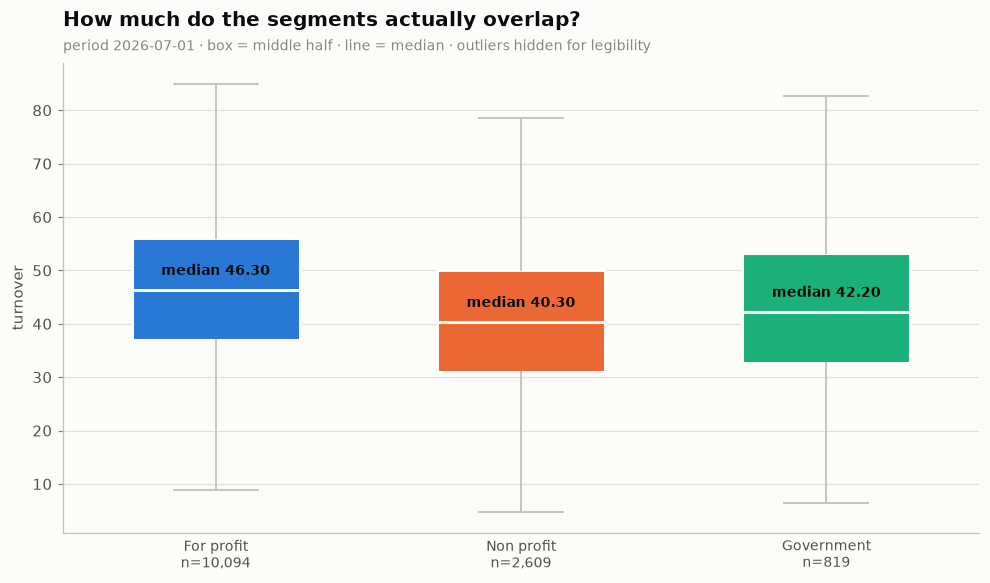

In [9]:
fig = charts.rating_box_by_segment(
    facilities, context, column="turnover",
    order=q.SEGMENTS["ownership_group"]["order"],
)
fig.savefig("bq2_turnover_box.png", dpi=150, bbox_inches="tight")
fig

## 8. คำตอบของ BQ2

_(สร้างจากตัวเลขจริง ไม่ได้พิมพ์มือ)_

In [10]:
fp = frame.loc[frame["segment"] == "For profit"].iloc[0]
np_ = frame.loc[frame["segment"] == "Non profit"].iloc[0]

print(f"งวด {context['period']} · ค่าปรับนับช่วง {context['fines_window']}\n")
print(f"{'':22}{'For profit':>13}{'Non profit':>13}{'Government':>13}")
rows = [("สถานพยาบาล", "facilities", "{:,.0f}"),
        ("เตียง", "beds", "{:,.0f}"),
        ("คะแนนดาวเฉลี่ย", "avg_rating", "{:.2f}"),
        ("ชม.พยาบาล/คน/วัน", "nurse_hprd", "{:.2f}"),
        ("สัดส่วน RN", "rn_share", "{:.1%}"),
        ("อัตราลาออก", "turnover_pct", "{:.1f}%"),
        ("ค่าปรับต่อเตียง", "fines_per_bed", "${:,.0f}"),
        ("% ที่เคยถูกปรับ", "share_fined", "{:.1%}")]
for label, col, fmt in rows:
    vals = "".join(fmt.format(frame.loc[frame['segment'] == s, col].iloc[0]).rjust(13)
                   for s in ["For profit", "Non profit", "Government"])
    print(f"{label:22}{vals}")

print(f"\nช่องว่างระหว่าง for-profit กับ non-profit")
print(f"  คะแนนดาว      ต่ำกว่า {np_['avg_rating'] - fp['avg_rating']:.2f} ดาว")
print(f"  ชั่วโมงพยาบาล  น้อยกว่า {np_['nurse_hprd'] - fp['nurse_hprd']:.2f} ชม./คน/วัน "
      f"({(np_['nurse_hprd'] / fp['nurse_hprd'] - 1) * 100:.0f}% น้อยกว่า)")
print(f"  ค่าปรับต่อเตียง สูงกว่า {fp['fines_per_bed'] / np_['fines_per_bed']:.2f} เท่า")

งวด 2026-07-01 · ค่าปรับนับช่วง 2023-07-01 to 2026-07-01

                         For profit   Non profit   Government
สถานพยาบาล                   10,845        2,875          947
เตียง                     1,203,047      258,261      105,567
คะแนนดาวเฉลี่ย                 2.80         3.57         3.28
ชม.พยาบาล/คน/วัน               3.62         4.21         4.17
สัดส่วน RN                    15.8%        19.4%        18.3%
อัตราลาออก                    45.8%        40.4%        42.4%
ค่าปรับต่อเตียง                $351         $224         $250
% ที่เคยถูกปรับ               48.7%        37.1%        43.7%

ช่องว่างระหว่าง for-profit กับ non-profit
  คะแนนดาว      ต่ำกว่า 0.77 ดาว
  ชั่วโมงพยาบาล  น้อยกว่า 0.59 ชม./คน/วัน (16% น้อยกว่า)
  ค่าปรับต่อเตียง สูงกว่า 1.57 เท่า


### สรุปสำหรับ CEO และ CFO

**For-profit ต่ำกว่าในทุกมิติคุณภาพ และเสี่ยงค่าปรับสูงกว่าอย่างชัดเจน**
ไม่ใช่ความต่างเล็กน้อย — ช่องว่างคะแนนดาว 0.77 บนสเกล 5 ระดับ และค่าปรับต่อเตียง
สูงกว่าราว 1.6 เท่า พร้อมกับชั่วโมงพยาบาลที่น้อยกว่าและสัดส่วนพยาบาลวิชาชีพที่ต่ำกว่า

**Government มีอัตราการเข้าพักต่ำกว่ากลุ่มอื่นชัดเจน** (72.8% เทียบกับ ~80%)
ซึ่งเป็นเรื่องเชิงพาณิชย์ ไม่ใช่คุณภาพ — น่าจะสะท้อนที่ตั้งในพื้นที่ประชากรน้อย

### ข้อจำกัด

1. **นี่คือความสัมพันธ์ ไม่ใช่สาเหตุ** for-profit อาจกระจุกในรัฐที่ Medicaid จ่ายต่ำ
   ทำให้จัดพยาบาลได้น้อยกว่าโดยไม่ใช่เพราะรูปแบบการถือครองเอง
   ต้องคุมตัวแปรรัฐก่อนจะสรุปเป็นสาเหตุ
2. **ค่าปรับผูกกับกลุ่มเจ้าของ ณ งวดนี้** ไม่ใช่ ณ วันที่ถูกปรับ เหตุผลอยู่ใน
   docstring ของ `segment_compare` — ทางเลือกอื่นจะเอาค่าปรับของกลุ่มหนึ่งไปหารเตียง
   ของอีกกลุ่ม สำหรับสถานพยาบาลครึ่งหนึ่งที่เปลี่ยนประเภท
3. **คะแนนดาวคือคุณภาพที่ CMS วัด** ไม่ใช่ผลลัพธ์ทางคลินิกโดยตรง